## Task 2: Data Profiling, Cleaning & EDA - Sudan
**Objective:** Profile, clean, and conduct a focused exploratory data analysis on the Sudan climate dataset 
**Author:** [Rahemet Huusen]
**Branch:** `eda-sudan`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Load the dataset
df = pd.read_csv("../data/sudan.csv")

# Add Country column
df['Country'] = 'Sudan'

# Convert YEAR and DOY into a datetime column
df['DATE'] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month for seasonal analysis
df['Month'] = df['DATE'].dt.month

df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,DATE,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


In [2]:
# 1. Replace NASA sentinel value -999 with NaN
df.replace(-999, np.nan, inplace=True)

# 2. Check for and drop duplicates
duplicates = df.duplicated().sum()
df.drop_duplicates(inplace=True)
print(f"Duplicate rows found and removed: {duplicates}")

# 3. Missing Value Report
missing_count = df.isna().sum()
missing_percent = (missing_count / len(df)) * 100
missing_report = pd.DataFrame({'Missing Values': missing_count, 'Percentage': missing_percent})

# Identify columns with >5% nulls
cols_above_5 = missing_report[missing_report['Percentage'] > 5]

print("\nMissing Value Report:")
print(missing_report)
print(f"\nColumns with >5% missing: {list(cols_above_5.index)}")

# 4. Summary Statistics
summary_stats = df.describe()
summary_stats

Duplicate rows found and removed: 0

Missing Value Report:
             Missing Values  Percentage
YEAR                      0         0.0
DOY                       0         0.0
T2M                       0         0.0
T2M_MAX                   0         0.0
T2M_MIN                   0         0.0
T2M_RANGE                 0         0.0
PRECTOTCORR               0         0.0
RH2M                      0         0.0
WS2M                      0         0.0
WS2M_MAX                  0         0.0
PS                        0         0.0
QV2M                      0         0.0
Country                   0         0.0
DATE                      0         0.0
Month                     0         0.0

Columns with >5% missing: []


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### Interpretation of Summary Statistics
- **Temperature (T2M):** Sudan shows a high mean temperature of ~28.7°C, with a maximum of ~38°C, highlighting the extreme heat profile of the region.
- **Precipitation (PRECTOTCORR):** The mean is very low (0.64 mm), but the max is 66.49 mm. This indicates that rainfall is infrequent but potentially heavy when it occurs (typical of arid/semi-arid regions).
- **Missing Values:** No columns exceeded the 5% threshold, suggesting a high-quality dataset for the selected period.

In [5]:
# Select target columns for outlier detection
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

# Compute Z-scores
z_scores = np.abs(stats.zscore(df[outlier_cols].fillna(df[outlier_cols].mean())))
outliers_mask = (z_scores > 3).any(axis=1)
outliers_count = outliers_mask.sum()

print(f"Total rows flagged as outliers (|Z| > 3): {outliers_count}")

# Handle missing values: Forward-fill weather variables
df.ffill(inplace=True)

# Final check: Drop rows if more than 30% values are missing (if any remained)
df = df.dropna(thresh=df.shape[1] * 0.7)

# Export cleaned data
# Ensure the 'data/' directory exists or create it
import os
if not os.path.exists('data'):
    os.makedirs('data')
df.to_csv("../data/sudan_clean.csv", index=False)

Total rows flagged as outliers (|Z| > 3): 84


### Outlier Handling Decision
- **Flagged Rows:** 84 rows were identified as outliers.
- **Reasoning:** I have chosen to **retain** these outliers. In climate data, extreme values for precipitation or wind speed often represent significant meteorological events (like flash floods or storms) rather than data errors. Removing them would bias the analysis toward "normal" weather and ignore the risks associated with climate extremes.

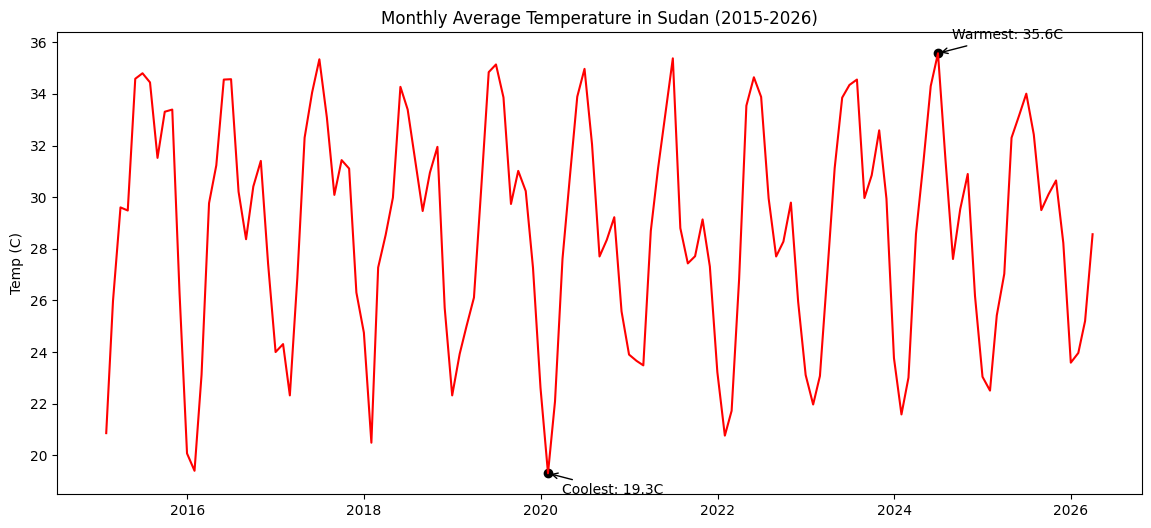

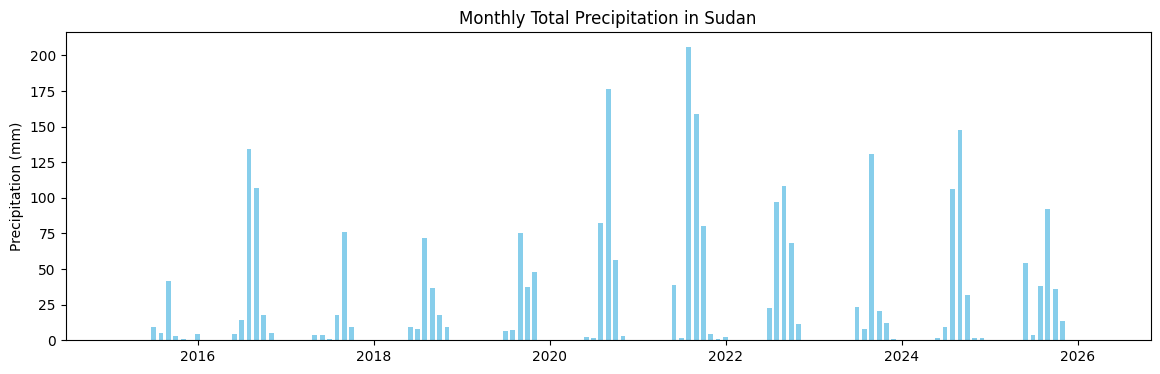

In [7]:
plt.figure(figsize=(14, 6))

# Monthly Average T2M - Updated 'M' to 'ME' for Pandas 3.0+
monthly_t2m = df.resample('ME', on='DATE')['T2M'].mean()
warmest_val, warmest_date = monthly_t2m.max(), monthly_t2m.idxmax()
coolest_val, coolest_date = monthly_t2m.min(), monthly_t2m.idxmin()

plt.plot(monthly_t2m.index, monthly_t2m.values, color='red')
plt.scatter([warmest_date, coolest_date], [warmest_val, coolest_val], color='black')

plt.annotate(f'Warmest: {warmest_val:.1f}C', xy=(warmest_date, warmest_val), xytext=(10, 10), 
             textcoords='offset points', arrowprops=dict(arrowstyle='->'))
plt.annotate(f'Coolest: {coolest_val:.1f}C', xy=(coolest_date, coolest_val), xytext=(10, -15), 
             textcoords='offset points', arrowprops=dict(arrowstyle='->'))

plt.title("Monthly Average Temperature in Sudan (2015-2026)")
plt.ylabel("Temp (C)")
plt.show()

# Monthly Total Precipitation - Updated 'M' to 'ME'
plt.figure(figsize=(14, 4))
monthly_precip = df.resample('ME', on='DATE')['PRECTOTCORR'].sum()
plt.bar(monthly_precip.index, monthly_precip.values, color='skyblue', width=20)
plt.title("Monthly Total Precipitation in Sudan")
plt.ylabel("Precipitation (mm)")
plt.show()

### Visual Trends
- **Seasonality:** Temperatures follow a predictable seasonal cycle, peaking annually.
- **Precipitation:** Rainfall is strictly seasonal (monsoonal), occurring primarily between July and September. Most months in Sudan show zero or near-zero precipitation, emphasizing the desert climate's vulnerability.


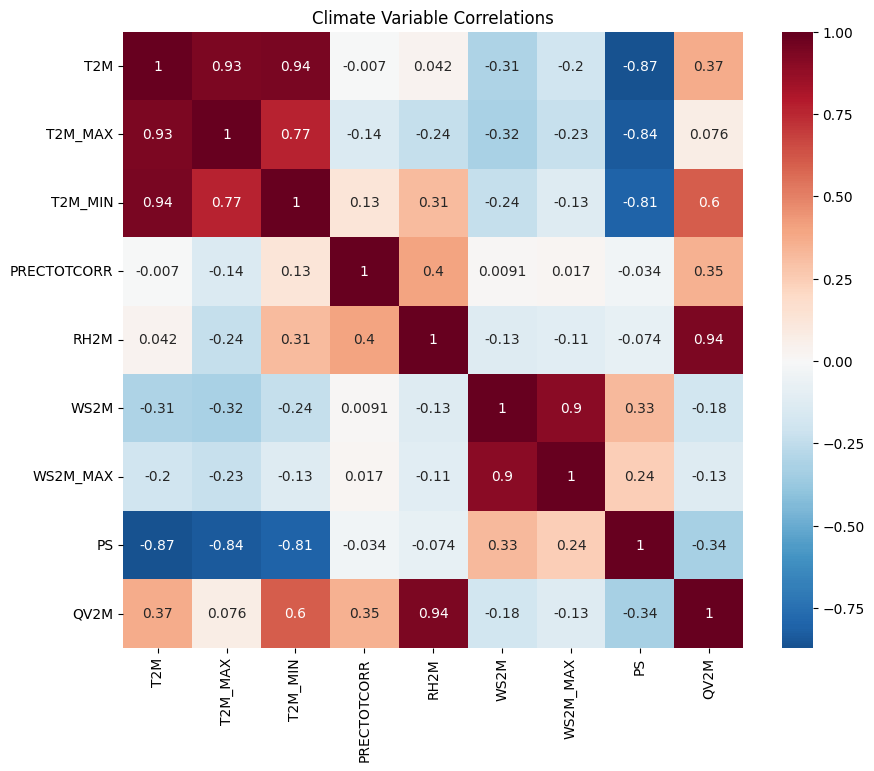

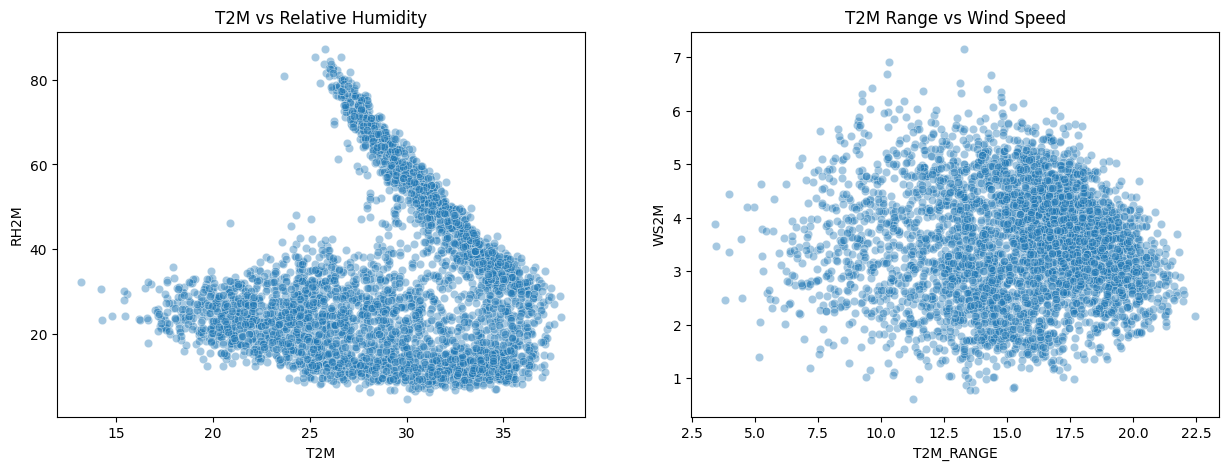

In [10]:
# Heatmap
plt.figure(figsize=(10, 8))
corr = df[outlier_cols + ['PS', 'QV2M']].corr()
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title("Climate Variable Correlations")
plt.show()

# Scatter Plots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.4, ax=axes[0])
axes[0].set_title("T2M vs Relative Humidity")

sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.4, ax=axes[1])
axes[1].set_title("T2M Range vs Wind Speed")
plt.show()
